# Price-Level Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('../data/processed_data.csv')

df.head()


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
1,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
2,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
3,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
4,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


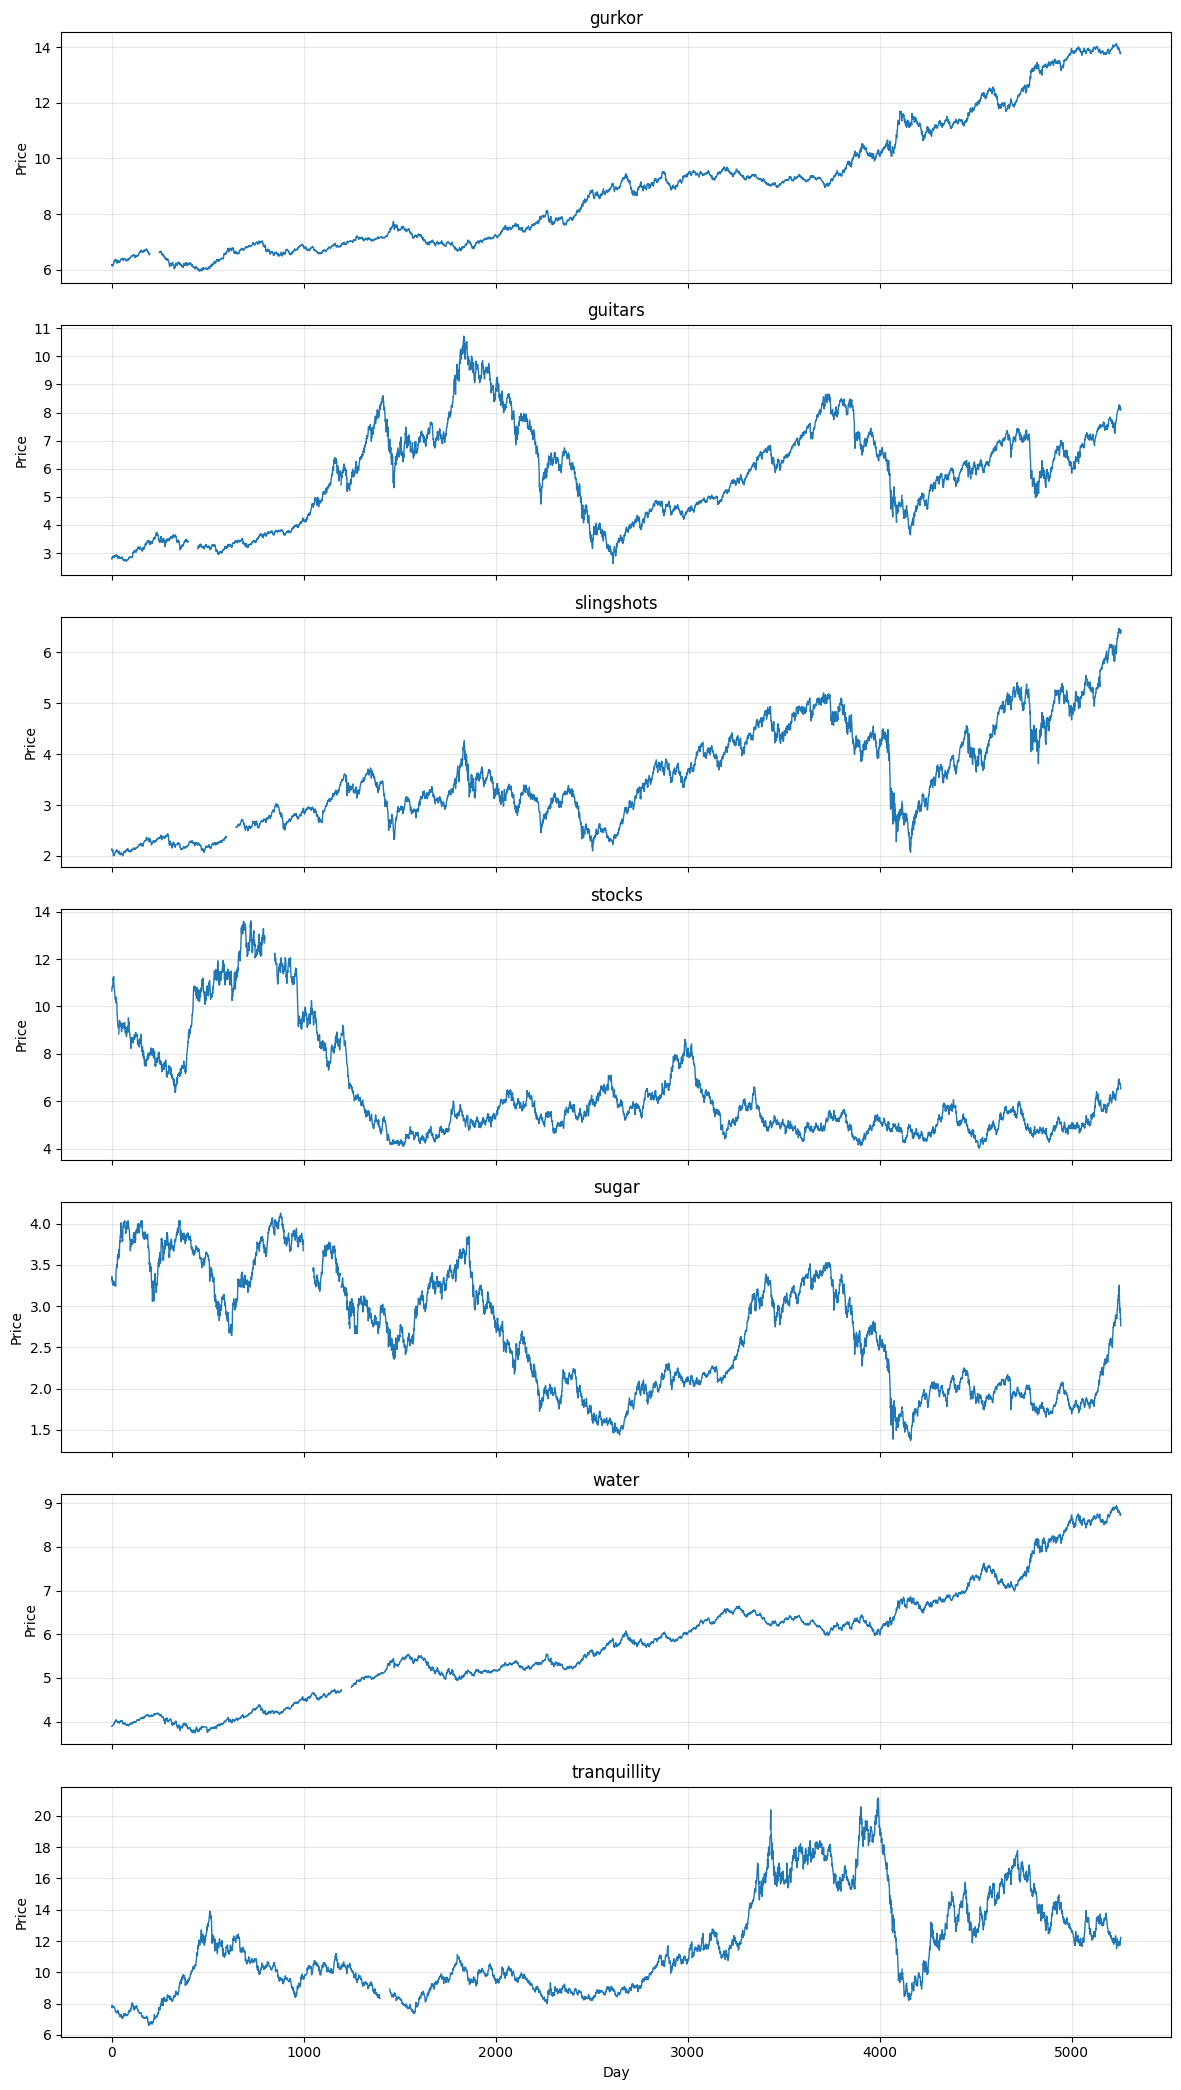

In [6]:
# We plot each time series separately
# This gives best overview of trends, seasonality, etc.

n = len(df.columns)
fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Day")
plt.tight_layout()
plt.show()

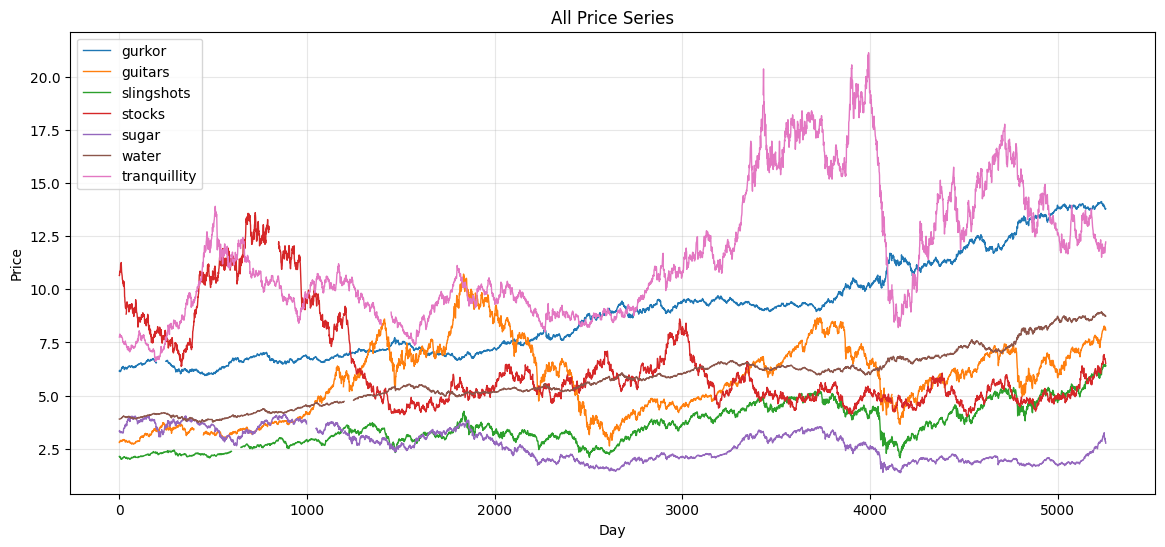

In [7]:
# Plotting together, good for seeing comparisons in scale
plt.figure(figsize=(14, 6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col, linewidth=1)
plt.title("All Price Series")
plt.xlabel("Day")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

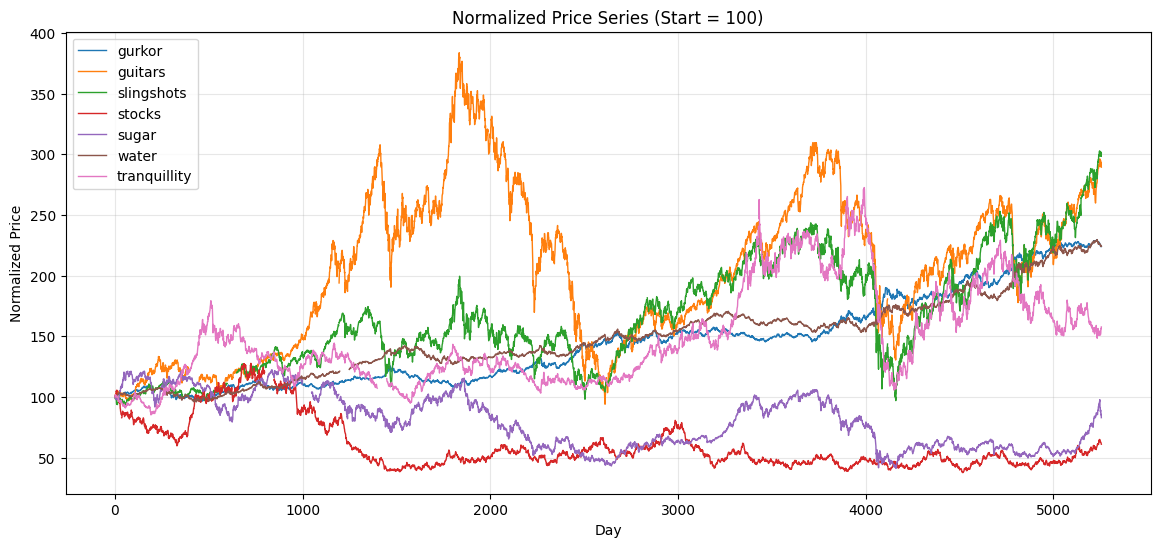

In [8]:
# Normalize to start at 100
normalized = df.copy()

for col in normalized.columns:
    first_valid = normalized[col].dropna().iloc[0]
    normalized[col] = normalized[col] / first_valid * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1)
plt.title("Normalized Price Series (Start = 100)")
plt.xlabel("Day")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

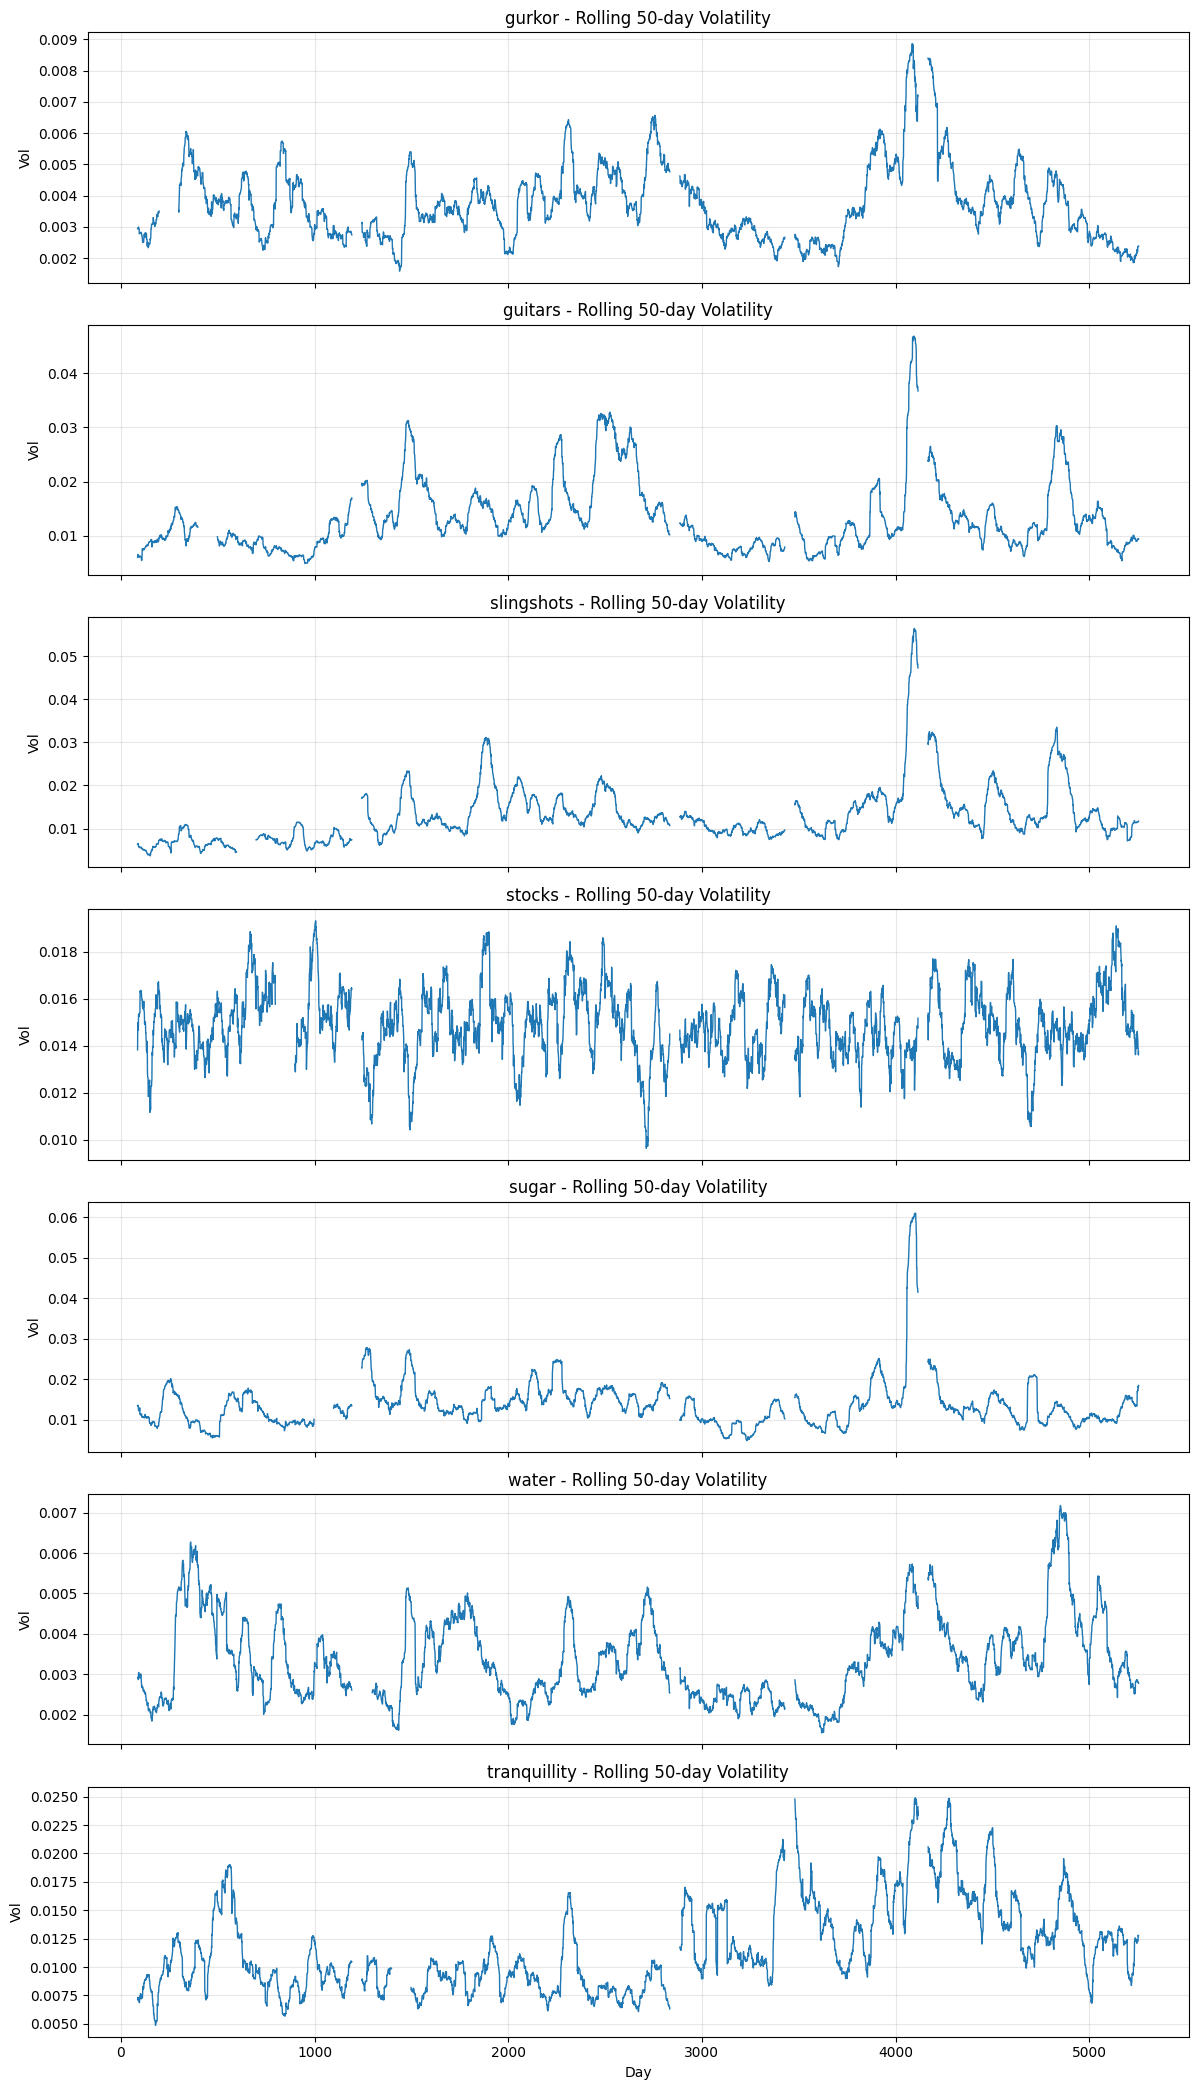

In [9]:
# Adding gliding volatility on price changes
# Volatility clustering looks better in returens, but this gives fast visual proxy

returns = df.pct_change()
rolling_vol = returns.rolling(50).std()

n = len(rolling_vol.columns)
fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, col in zip(axes, rolling_vol.columns):
    ax.plot(rolling_vol.index, rolling_vol[col], linewidth=1)
    ax.set_title(f"{col} - Rolling 50-day Volatility")
    ax.set_ylabel("Vol")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Day")
plt.tight_layout()
plt.show()


In [10]:
# Summary statistics
summary = pd.DataFrame({
    "min": df.min(),
    "max": df.max(),
    "mean": df.mean(),
    "std": df.std(),
    "start": df.apply(lambda s: s.dropna().iloc[0]),
    "end_observed": df.apply(lambda s: s.dropna().iloc[-1]),
})

summary["growth_ratio"] = summary["end_observed"] / summary["start"]
summary = summary.sort_values("growth_ratio", ascending=False)

summary

,min,max,mean,std,start,end_observed,growth_ratio
slingshots,2.001362,6.468982,3.562496,0.973406,2.136536,6.419011,3.004402
guitars,2.629048,10.719387,5.758999,1.756993,2.794285,8.084917,2.893376
water,3.739412,8.949187,5.794586,1.275024,3.896149,8.738561,2.242871
gurkor,5.942896,14.132395,8.934701,2.268289,6.154653,13.791949,2.240898
tranquillity,6.614749,21.137953,11.552924,3.067634,7.755880,12.231405,1.577049
sugar,1.370262,4.125193,2.663530,0.727010,3.324896,2.760591,0.830279
stocks,4.012346,13.613052,6.354767,2.139400,10.653684,6.512971,0.611335


In [13]:
# Similarity in normalised price levels

norm_corr = normalized.corr()
norm_corr



,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000000,0.238487,0.753631,-0.512937,-0.681986,0.970707,0.530684
guitars,0.238487,1.000000,0.614809,-0.620228,-0.040941,0.397039,0.383696
slingshots,0.753631,0.614809,1.000000,-0.496959,-0.279750,0.822367,0.745368
stocks,-0.512937,-0.620228,-0.496959,1.000000,0.523070,-0.628170,-0.283928
sugar,-0.681986,-0.040941,-0.279750,0.523070,1.000000,-0.677335,-0.096623
water,0.970707,0.397039,0.822367,-0.628170,-0.677335,1.000000,0.521905
tranquillity,0.530684,0.383696,0.745368,-0.283928,-0.096623,0.521905,1.000000


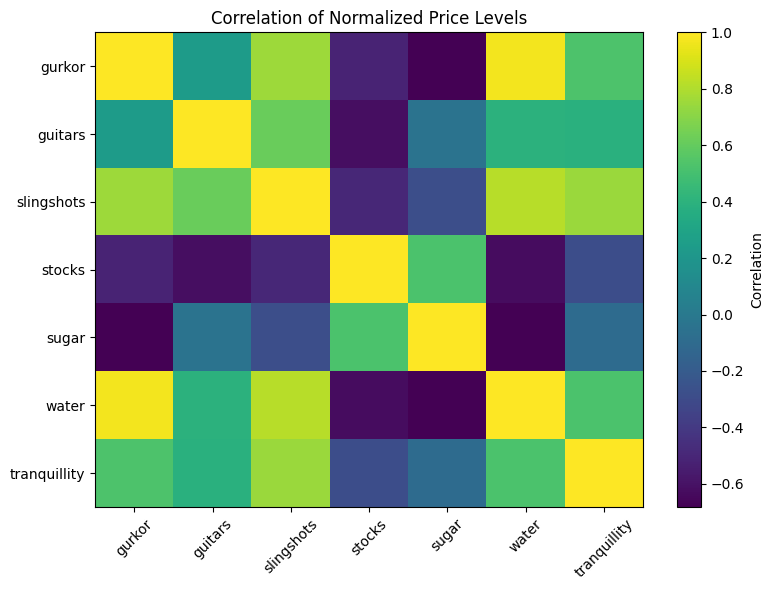

In [14]:
plt.figure(figsize=(8, 6))
plt.imshow(norm_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(norm_corr.columns)), norm_corr.columns, rotation=45)
plt.yticks(range(len(norm_corr.index)), norm_corr.index)
plt.title("Correlation of Normalized Price Levels")
plt.tight_layout()
plt.show()

## Analysis

The normalized price series reveal clear differences in growth dynamics and co-movement across assets. A strong cluster consisting of gurkor and water is observed, with near-identical trajectories and extremely high correlation (≈0.97), indicating exposure to a common underlying factor.

The slingshots series closely follows this cluster, suggesting it belongs to the same broader market segment. The guitars series exhibits partial co-movement with this group but shows significantly higher volatility and large deviations, indicating an additional idiosyncratic component.

In contrast, stocks and sugar behave very differently from the rest of the assets. Both show weak or negative correlations with the main cluster, and their normalized price paths diverge substantially. Notably, both assets exhibit declining long-term performance, with growth ratios below 1, suggesting fundamentally different underlying dynamics.

The tranquillity series appears to occupy an intermediate position, partially following the main cluster but also displaying independent behavior at several periods.

The presence of both strongly correlated clusters and negatively correlated assets suggests that the dataset contains multiple underlying factors rather than a single integrated market.

These structural differences suggest that different modeling approaches may be appropriate for different groups of assets in subsequent interpolation and forecasting tasks.